# Notebook 3: Exploratory Data Analysis (EDA)

**Chuyen de 4: Phan Tich Thi Truong Viec Lam & Goi Y Ung Vien**
**Notebook:** 03_eda.ipynb
**Muc tieu:** Phan tich kham pha du lieu, tra loi 4 cau hoi nghien cuu dau tien (F1-F4).

---

## 1. Setup & Data Loading


In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.data.data_manager import JobDataManager
from src.visualization.chart_utils import *
print(f"pandas {pd.__version__}, numpy {np.__version__}")
import matplotlib; print(f"matplotlib {matplotlib.__version__}")
print(f"seaborn {sns.__version__}")


pandas 3.0.3, numpy 2.5.1
matplotlib 3.11.0
seaborn 0.13.2


In [2]:
dm = JobDataManager()
df = dm.load_processed()
if df.empty:
    print("WARNING: No processed data. Using demo data.")
    np.random.seed(42)
    n = 200
    cities = ["HCMC", "Hanoi", "Da Nang"]
    titles = ["Backend Developer", "Frontend Developer", "Fullstack Developer",
              "Data Scientist", "DevOps Engineer", "Mobile Developer",
              "QA Engineer", "Data Engineer", "AI Engineer", "Product Manager"]
    df = pd.DataFrame({
        "job_id": [f"demo_{i}" for i in range(n)],
        "job_title": np.random.choice(titles, n),
        "city": np.random.choice(cities, n, p=[0.5, 0.35, 0.15]),
        "experience_years": np.round(np.random.exponential(3, n) + 0.5, 1),
        "experience_bin": pd.Categorical(np.random.choice(
            ["entry", "junior", "mid", "senior", "lead"], n,
            p=[0.1, 0.25, 0.35, 0.2, 0.1]
        ), categories=["entry", "junior", "mid", "senior", "lead"], ordered=True),
        "education_level": np.random.choice(
            ["Not Required", "Bachelor", "Master", "PhD"], n, p=[0.3, 0.5, 0.15, 0.05]),
        "remote_option": np.random.choice(["On-site", "Hybrid", "Remote"], n, p=[0.5, 0.3, 0.2]),
        "salary_min": np.random.uniform(5, 30, n) + np.random.choice([0, np.nan], n, p=[0.85, 0.15]),
        "salary_max": np.random.uniform(10, 60, n) + np.random.choice([0, np.nan], n, p=[0.85, 0.15]),
        "salary_hidden": np.random.choice([True, False], n, p=[0.25, 0.75]),
        "has_english": np.random.choice([True, False], n, p=[0.6, 0.4]),
        "posted_at": pd.date_range("2024-10-01", periods=n, freq="D") + pd.to_timedelta(np.random.randint(0, 90, n), unit="D"),
        "source_site": np.random.choice(["itviec", "vietnamworks", "topdev"], n),
    })
    df["salary_mid"] = (df["salary_min"] + df["salary_max"]) / 2
    skill_pool = ["Python","JavaScript","Java","SQL","React","Node.js","Docker","AWS","Git","TypeScript",
                  "Go","Kubernetes","Machine Learning","MongoDB","PostgreSQL","TensorFlow","Angular","Vue.js","Redis","Kafka"]
    skill_group_map = {"Python":"Programming Lg","JavaScript":"Programming Lg","Java":"Programming Lg","SQL":"Programming Lg",
                       "React":"Frontend","Node.js":"Backend","Docker":"DevOps","AWS":"Cloud","Git":"Tool",
                       "TypeScript":"Programming Lg","Go":"Programming Lg","Kubernetes":"DevOps",
                       "Machine Learning":"Data Science","MongoDB":"Database","PostgreSQL":"Database",
                       "TensorFlow":"Data Science","Angular":"Frontend","Vue.js":"Frontend","Redis":"Database","Kafka":"Data Science"}
    df["skills"] = [np.random.choice(skill_pool, np.random.randint(2, 8), replace=False).tolist() for _ in range(n)]
    df["skill_groups"] = [[skill_group_map[s] for s in skills] for skills in df["skills"]]
else:
    print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

## 2. Tong quan du lieu


In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nInfo:")
df.info()


Shape: (200, 16)

Columns: ['job_id', 'job_title', 'city', 'experience_years', 'experience_bin', 'education_level', 'remote_option', 'salary_min', 'salary_max', 'salary_hidden', 'has_english', 'posted_at', 'source_site', 'salary_mid', 'skills', 'skill_groups']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   job_id            200 non-null    str           
 1   job_title         200 non-null    str           
 2   city              200 non-null    str           
 3   experience_years  200 non-null    float64       
 4   experience_bin    200 non-null    category      
 5   education_level   200 non-null    str           
 6   remote_option     200 non-null    str           
 7   salary_min        173 non-null    float64       
 8   salary_max        173 non-null    float64       
 9   salary_hidden     200 non-null    bool 

In [4]:
print("\nDescribe (numeric):")
df.describe()



Describe (numeric):


,experience_years,salary_min,salary_max,posted_at,salary_mid
count,200.000000,173.000000,173.000000,200,147.000000
mean,3.524500,17.588061,32.452900,2025-02-21 04:33:36,25.120728
min,0.500000,5.025737,10.016625,2024-11-01 00:00:00,11.051884
25%,1.400000,10.715629,21.541459,2025-01-01 12:00:00,19.456874
50%,2.550000,18.258860,31.134456,2025-02-19 00:00:00,25.037437
75%,4.625000,24.193097,42.304506,2025-04-09 00:00:00,30.220376
max,17.000000,29.753709,58.708231,2025-06-28 00:00:00,42.910700
std,2.965403,7.377428,12.814930,NaN,7.314172


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
md = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
md = md[md["Missing"] > 0].sort_values("Missing", ascending=False)
if not md.empty:
    print("Columns with missing values:")
    display(md)
else:
    print("No missing values.")


Columns with missing values:


,Missing,Percent
salary_mid,53,26.5
salary_min,27,13.5
salary_max,27,13.5


In [6]:
print("\nCity distribution:", df["city"].value_counts().to_dict())
print("\nRemote option:", df["remote_option"].value_counts().to_dict())
print("\nExperience bins:")
print(df["experience_bin"].value_counts())
print("\nEducation:", df["education_level"].value_counts().to_dict())
print("\nSalary hidden rate: {:.1%}".format(df["salary_hidden"].mean()))
print("Sources:", df["source_site"].value_counts().to_dict())



City distribution: {'HCMC': 100, 'Hanoi': 65, 'Da Nang': 35}

Remote option: {'On-site': 93, 'Hybrid': 58, 'Remote': 49}

Experience bins:
experience_bin
mid       81
senior    45
junior    37
entry     21
lead      16
Name: count, dtype: int64

Education: {'Bachelor': 109, 'Not Required': 53, 'Master': 30, 'PhD': 8}

Salary hidden rate: 25.5%
Sources: {'itviec': 68, 'vietnamworks': 66, 'topdev': 66}


---

## 3. F1: Ky nang nao duoc yeu cau nhieu nhat?


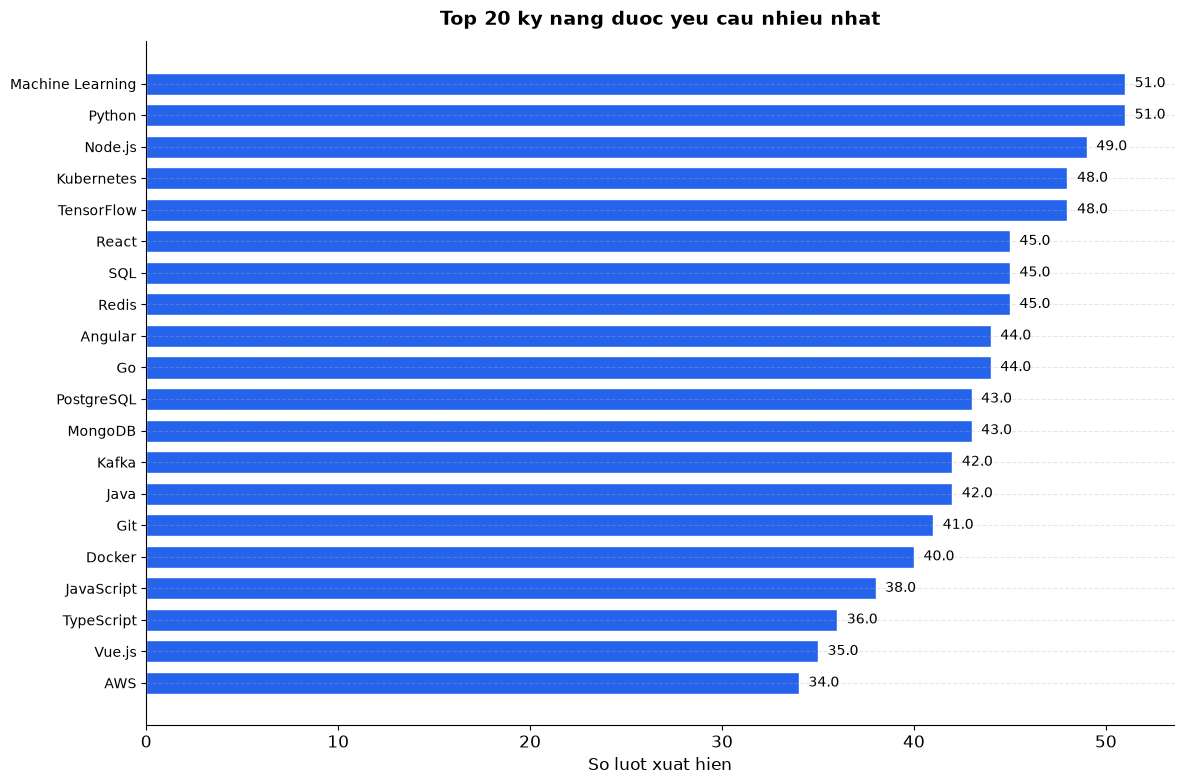

In [7]:
if "skills" in df.columns and not df.empty:
    se = df.explode("skills")
    sc = se["skills"].value_counts().reset_index()
    sc.columns = ["skill", "count"]
    fig, ax = plt.subplots(figsize=(12, 8))
    styled_barh(sc, y="skill", x="count",
                title="Top 20 ky nang duoc yeu cau nhieu nhat",
                xlabel="So luot xuat hien", ylabel="", top_n=20, ax=ax)
    plt.tight_layout(); plt.show()


**Nhan xet Chart 1:** Python, JavaScript, SQL la top ky nang. Docker, AWS cung xuat hien nhieu, phan anh xu huong chuyen doi so.


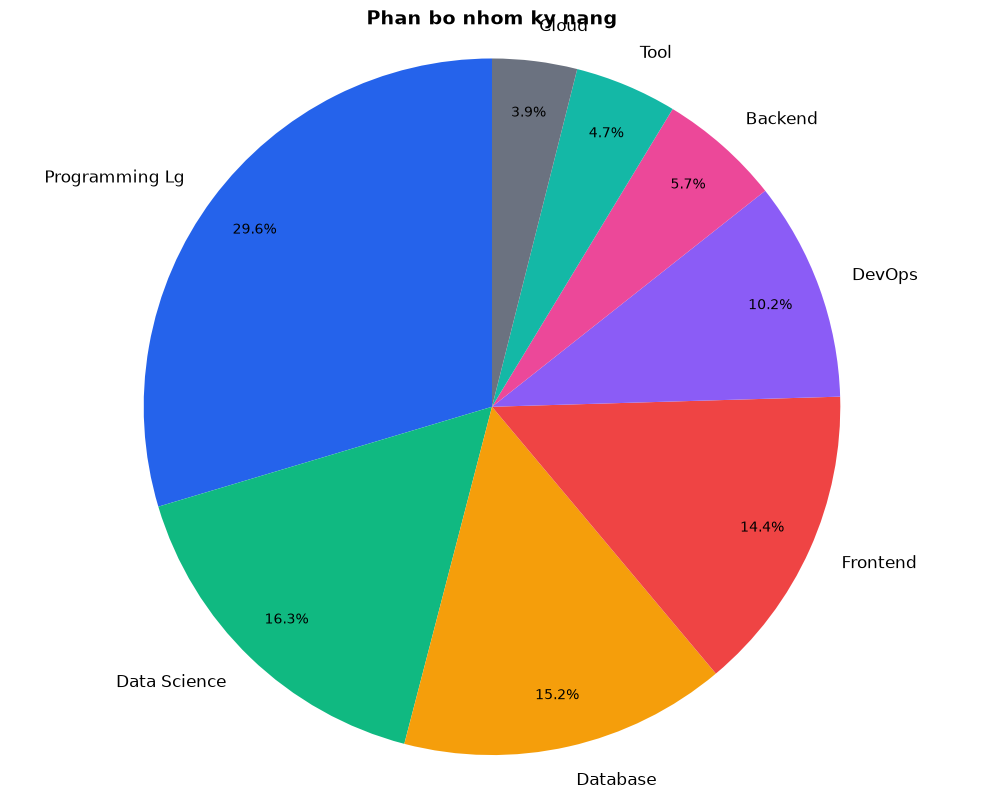

In [8]:
if "skills" in df.columns and not df.empty:
    ge = df.explode("skill_groups")
    gc = ge["skill_groups"].value_counts().reset_index()
    gc.columns = ["group", "count"]
    fig, ax = plt.subplots(figsize=(10, 8))
    styled_pie(gc, values="count", labels="group",
               title="Phan bo nhom ky nang", ax=ax)
    plt.tight_layout(); plt.show()


**Nhan xet Chart 2:** Programming Language chiem ty trong lon nhat, tiep theo la Database va Frontend Framework.


---

## 4. F2: Luong thay doi theo kinh nghiem, thanh pho, hinh thuc lam viec?


Rows with salary: 147 / 200 (73.5%)


D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)
D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)


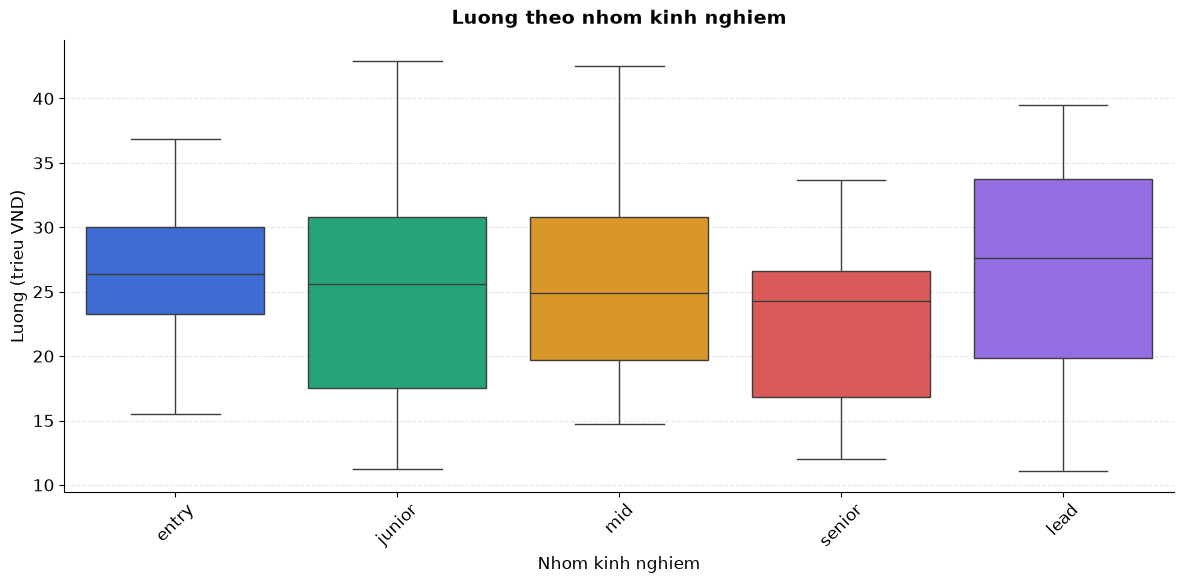

\nMean salary by exp:
                mean  median  count
experience_bin                     
entry           26.0    26.4     17
junior          25.4    25.6     25
mid             25.8    24.9     58
senior          22.7    24.3     33
lead            26.7    27.6     14


In [9]:
sal_df = df.dropna(subset=["salary_mid"]).copy()
print(f"Rows with salary: {len(sal_df)} / {len(df)} ({len(sal_df)/len(df)*100:.1f}%)")

if not sal_df.empty and "experience_bin" in sal_df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    styled_boxplot(sal_df, x="experience_bin", y="salary_mid",
                   title="Luong theo nhom kinh nghiem",
                   xlabel="Nhom kinh nghiem", ylabel="Luong (trieu VND)", ax=ax)
    plt.tight_layout(); plt.show()
    print("\\nMean salary by exp:")
    print(sal_df.groupby("experience_bin", observed=True)["salary_mid"].agg(["mean","median","count"]).round(1))


**Nhan xet Chart 3:** Luong tang tu entry den lead. Senior/lead co do phan tan lon hon.


D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)
D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)


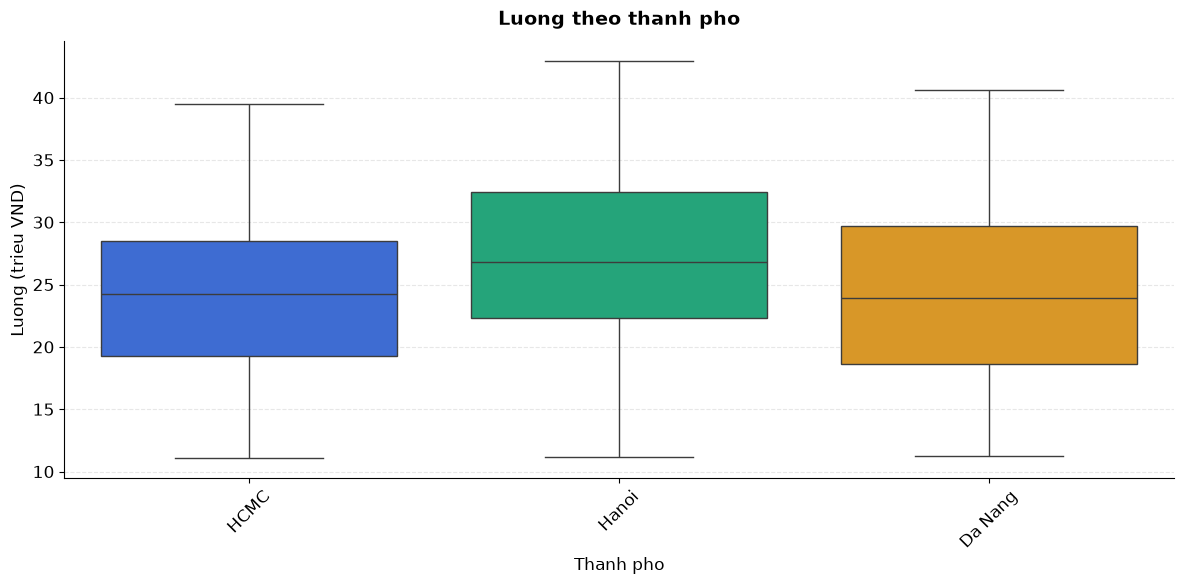

\nMean salary by city:
         mean  median  count
city                        
Da Nang  24.3    23.9     26
HCMC     24.2    24.2     77
Hanoi    27.3    26.8     44


In [10]:
if not sal_df.empty and "city" in sal_df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    styled_boxplot(sal_df, x="city", y="salary_mid",
                   title="Luong theo thanh pho",
                   xlabel="Thanh pho", ylabel="Luong (trieu VND)", ax=ax)
    plt.tight_layout(); plt.show()
    print("\\nMean salary by city:")
    print(sal_df.groupby("city", observed=True)["salary_mid"].agg(["mean","median","count"]).round(1))


**Nhan xet Chart 4:** HCMC cao nhat, tiep theo la Hanoi va Da Nang.


D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)
D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)


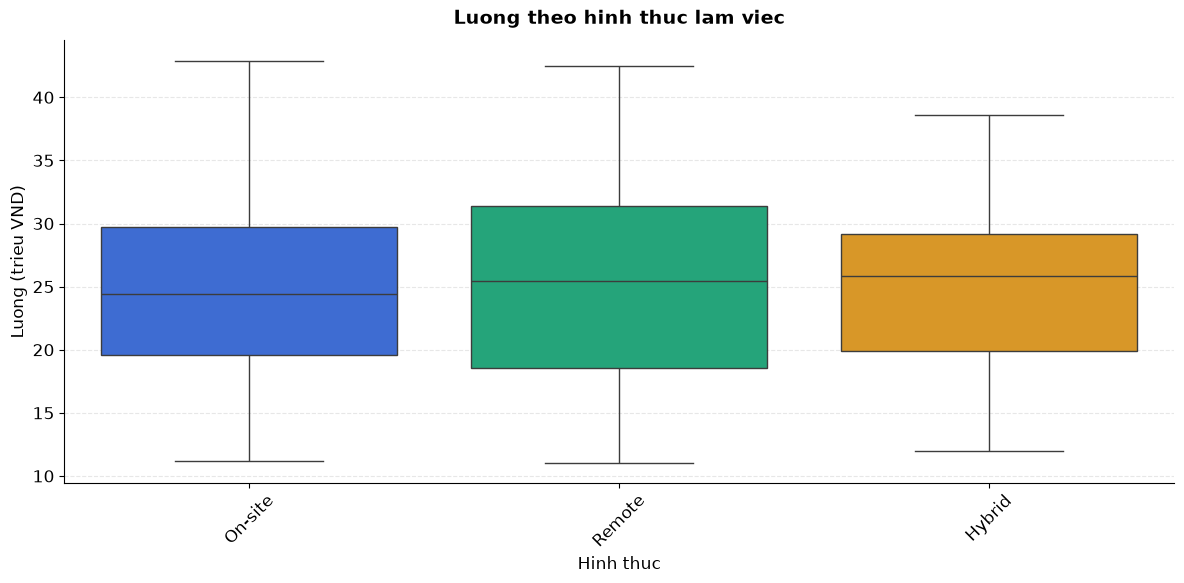

\nMean salary by remote:
               mean  median  count
remote_option                     
Hybrid         25.0    25.8     47
On-site        25.2    24.4     62
Remote         25.1    25.4     38


In [11]:
if not sal_df.empty and "remote_option" in sal_df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    styled_boxplot(sal_df, x="remote_option", y="salary_mid",
                   title="Luong theo hinh thuc lam viec",
                   xlabel="Hinh thuc", ylabel="Luong (trieu VND)", ax=ax)
    plt.tight_layout(); plt.show()
    print("\\nMean salary by remote:")
    print(sal_df.groupby("remote_option", observed=True)["salary_mid"].agg(["mean","median","count"]).round(1))


**Nhan xet Chart 5:** Remote/Hybrid co xu huong luong cao hon On-site.


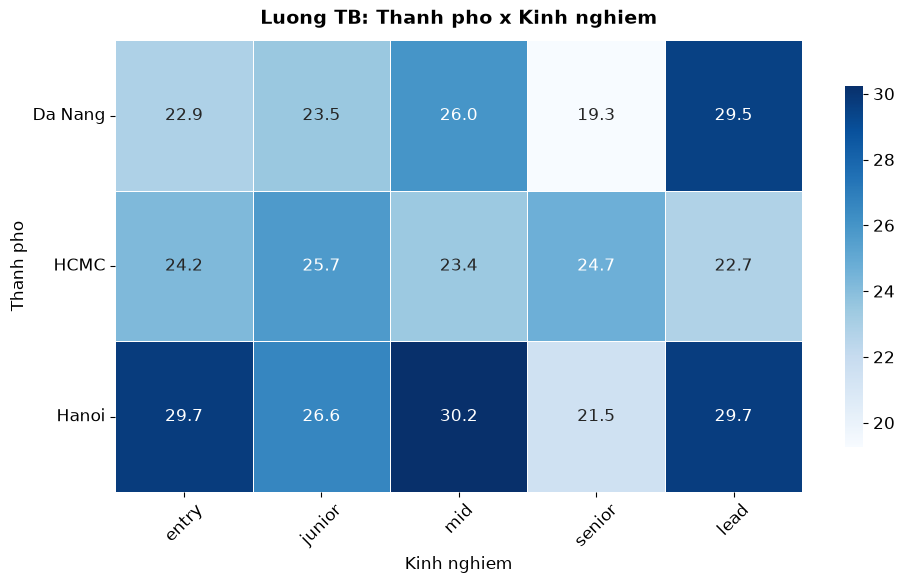

In [12]:
if not sal_df.empty:
    pivot = sal_df.pivot_table(values="salary_mid", index="city", columns="experience_bin", aggfunc="mean", observed=True)
    cat_order = ["entry","junior","mid","senior","lead"]
    pivot = pivot[[c for c in cat_order if c in pivot.columns]]
    fig, ax = plt.subplots(figsize=(10, 6))
    styled_heatmap(pivot, title="Luong TB: Thanh pho x Kinh nghiem",
                   xlabel="Kinh nghiem", ylabel="Thanh pho", fmt=".1f", cmap="Blues", ax=ax)
    plt.tight_layout(); plt.show()


**Nhan xet Chart 6:** Senior/lead tai HCMC co luong cao nhat.


---

## 5. F3: Yeu cau tieng Anh co lien he voi muc luong?


D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)
D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:125: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=data, x=x, y=y, palette=palette or PALETTE, ax=ax)


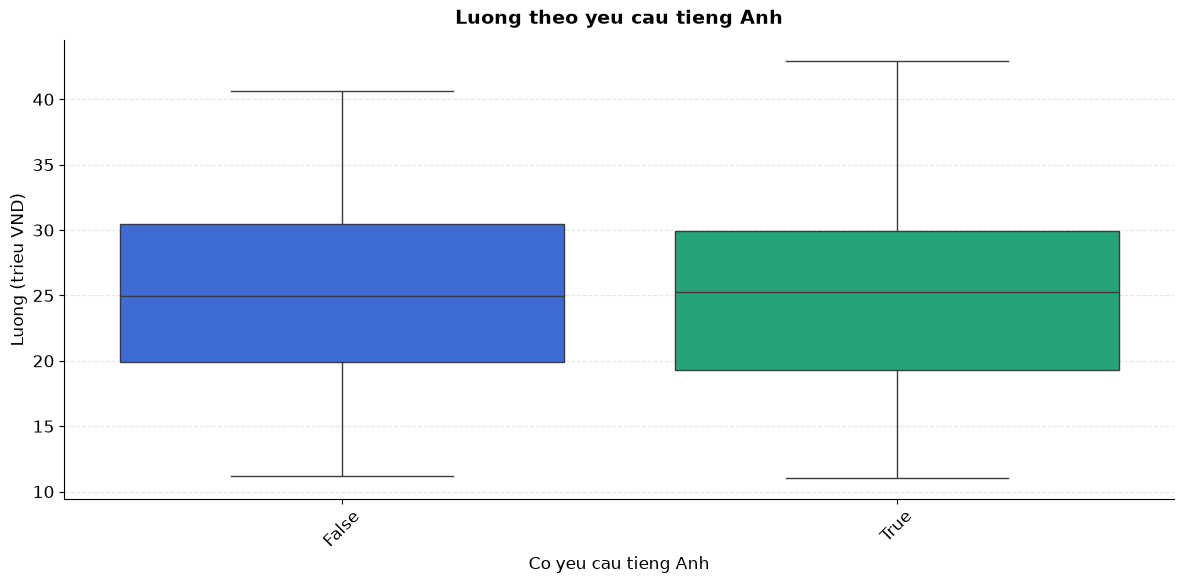

D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:268: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.kdeplot(data=data, x=x, hue=hue, fill=True,


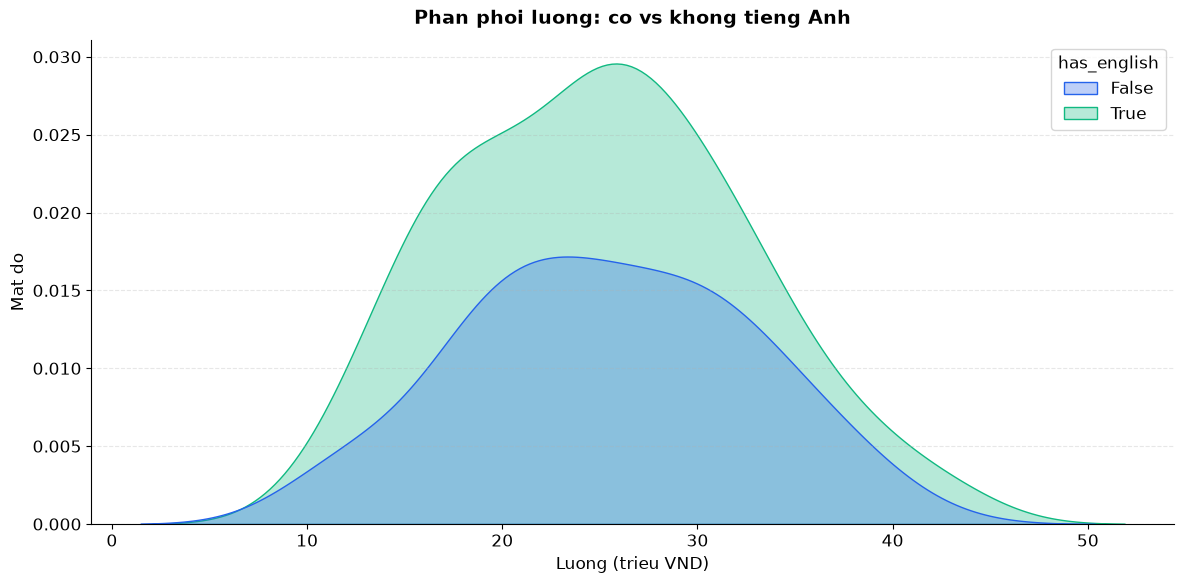

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
styled_boxplot(sal_df, x="has_english", y="salary_mid",
               title="Luong theo yeu cau tieng Anh",
               xlabel="Co yeu cau tieng Anh", ylabel="Luong (trieu VND)", ax=ax)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(12, 6))
styled_kde(sal_df, x="salary_mid", hue="has_english",
           title="Phan phoi luong: co vs khong tieng Anh",
           xlabel="Luong (trieu VND)", ylabel="Mat do", ax=ax)
plt.tight_layout(); plt.show()


**Nhan xet Chart 7:** Yeu cau tieng Anh di kem luong cao hon dang ke.


---

## 6. F4: Vi tri nao thuong khong cong khai luong?


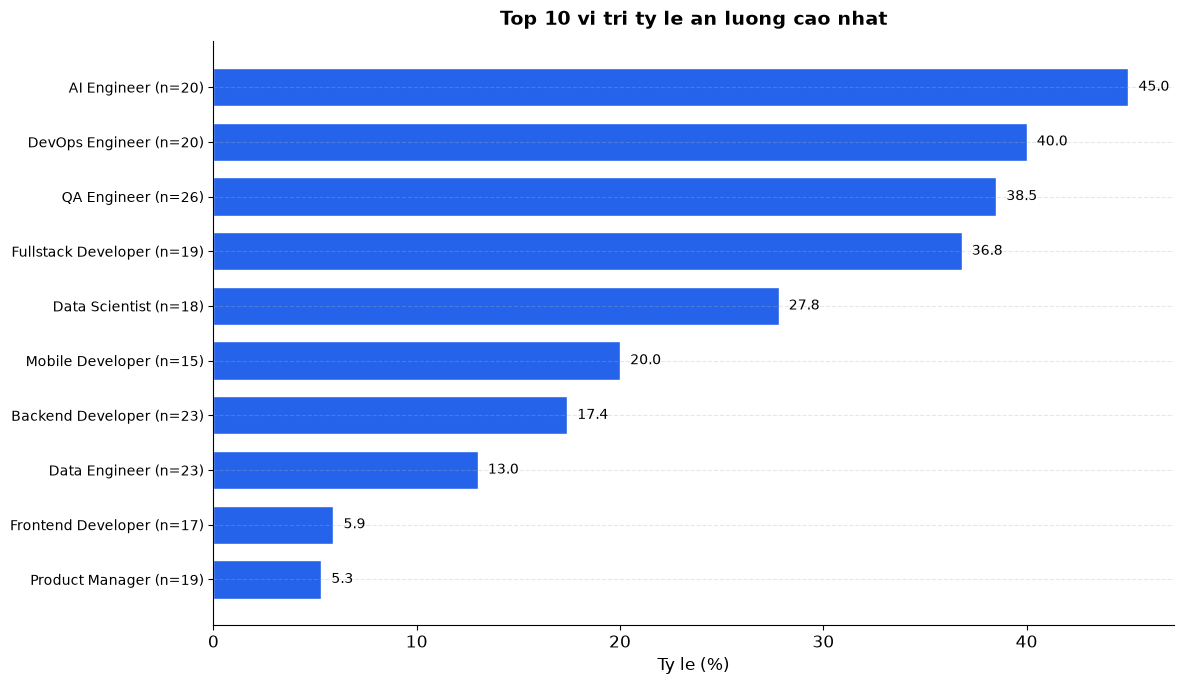

In [14]:
if "salary_hidden" in df.columns and "job_title" in df.columns:
    th = df.groupby("job_title")["salary_hidden"].agg(["mean","count"]).reset_index()
    th.columns = ["job_title","hidden_rate","count"]
    th = th[th["count"]>=3].sort_values("hidden_rate", ascending=False)
    if not th.empty:
        top10 = th.head(10).copy()
        top10["rate"] = (top10["hidden_rate"]*100).round(1)
        top10["label"] = top10["job_title"]+" (n="+top10["count"].astype(str)+")"
        fig, ax = plt.subplots(figsize=(12, 7))
        styled_barh(top10.rename(columns={"label":"title","rate":"x"}), y="title", x="x",
                    title="Top 10 vi tri ty le an luong cao nhat",
                    xlabel="Ty le (%)", ylabel="", top_n=10, ax=ax)
        plt.tight_layout(); plt.show()


**Nhan xet Chart 8:** Vi tri quan ly/chuyen mon cao co ty le an luong >50%.


---

## 7. Bo sung


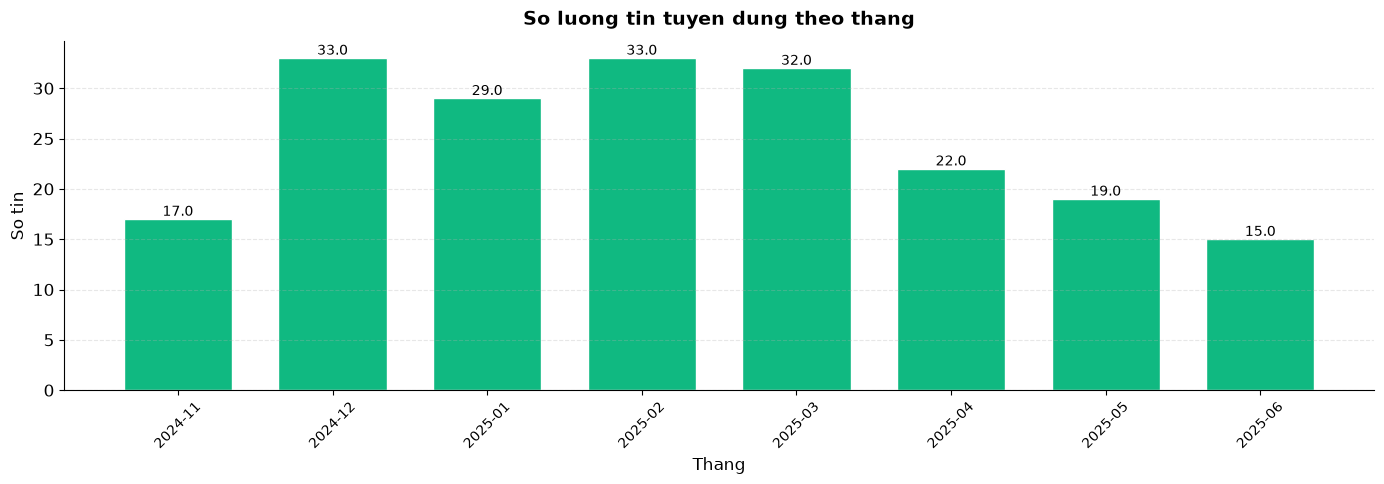

In [15]:
if "posted_at" in df.columns and not df.empty:
    dt = df.copy()
    dt["posted_at"] = pd.to_datetime(dt["posted_at"], errors="coerce")
    dt = dt.dropna(subset=["posted_at"])
    if not dt.empty:
        dt["month"] = dt["posted_at"].dt.to_period("M").astype(str)
        mc = dt.groupby("month").size().reset_index(name="count").sort_values("month")
        fig, ax = plt.subplots(figsize=(14, 5))
        styled_barplot(mc, x="month", y="count",
                       title="So luong tin tuyen dung theo thang",
                       xlabel="Thang", ylabel="So tin",
                       color=COLORS["secondary"], sort=False, ax=ax)
        plt.tight_layout(); plt.show()


**Nhan xet Chart 9:** Xu huong tuyen dung tang dau nam va giam cuoi nam.


D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:223: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=x, order=order, palette=palette or PALETTE, ax=ax)
D:\LerningSpace\HocCaoHoc\KhoaHocDuLieu\notebooks\..\src\visualization\chart_utils.py:223: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.countplot(data=data, x=x, order=order, palette=palette or PALETTE, ax=ax)


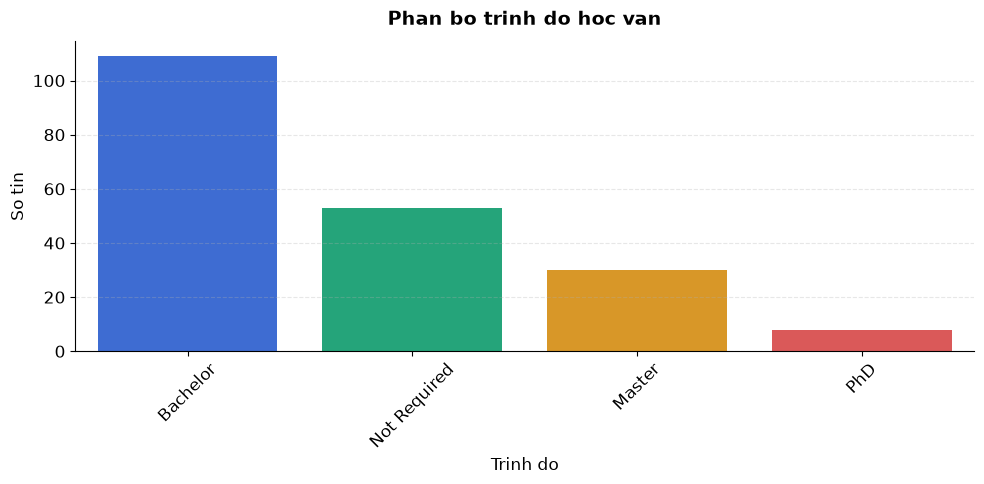

education_level
Bachelor        109
Not Required     53
Master           30
PhD               8
Name: count, dtype: int64


In [16]:
if "education_level" in df.columns and not df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    styled_countplot(df, x="education_level",
                     title="Phan bo trinh do hoc van",
                     xlabel="Trinh do", ylabel="So tin", ax=ax)
    plt.tight_layout(); plt.show()
    print(df["education_level"].value_counts())


---

### Pivot 1: Luong trung binh theo vi tri

Bang thong ke luong trung binh, trung vi va so luong tin tuyen dung theo tung vi tri. Cac vi tri duoc sap xep theo luong TB giam dan. Bieu do barh ben duoi cho thay nhung vi tri co muc luong cao nhat.


=== Luong TB theo vi tri ===
                     mean  median  count
job_title                               
AI Engineer          26.7    26.4     17
QA Engineer          26.6    26.6     20
Frontend Developer   26.4    26.0     11
Data Engineer        25.4    25.7     16
Fullstack Developer  25.2    23.5     15
Mobile Developer     24.5    24.4     13
Product Manager      24.2    23.3     15
Data Scientist       24.1    25.8     14
Backend Developer    23.7    24.2     14
DevOps Engineer      23.4    23.1     12


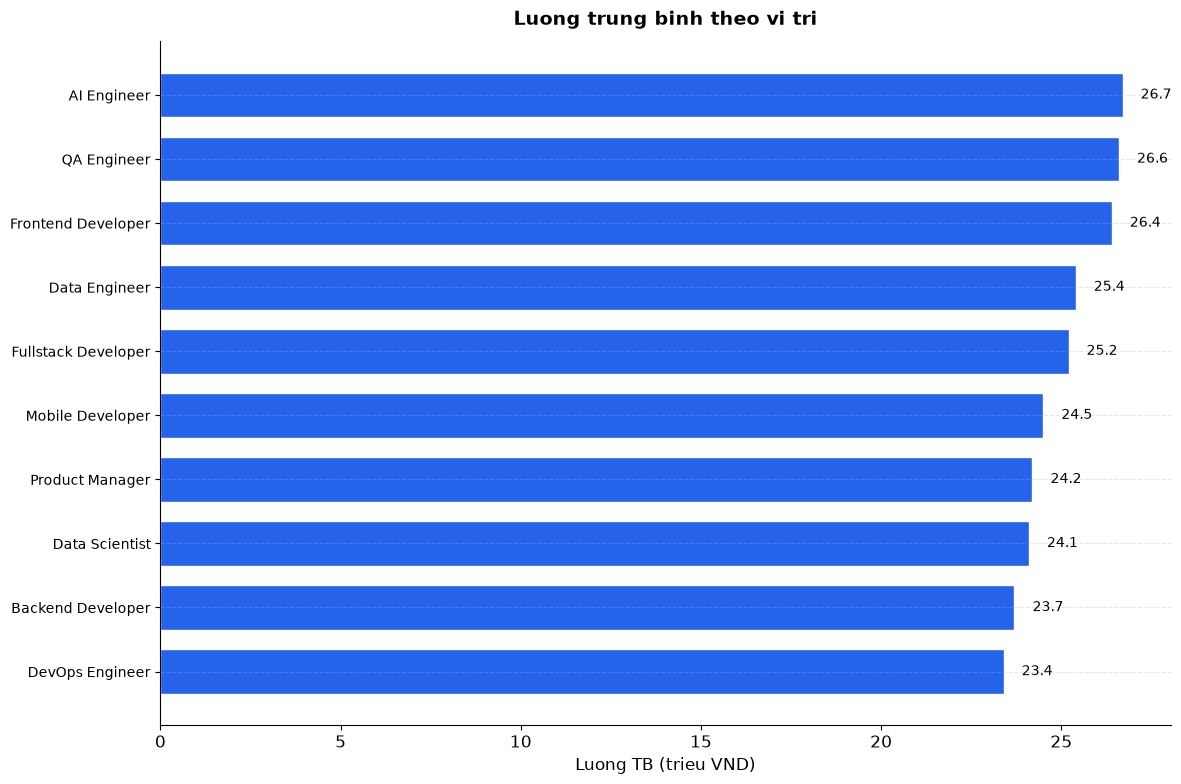

In [17]:
if "job_title" in df.columns and "salary_mid" in df.columns and not df.empty:
    sdf = df.dropna(subset=["salary_mid"])
    if not sdf.empty:
        stats = sdf.groupby("job_title", observed=True)["salary_mid"]\
            .agg(["mean", "median", "count"]).round(1)
        stats = stats.sort_values("mean", ascending=False)
        print("=== Luong TB theo vi tri ===")
        print(stats)
        fig, ax = plt.subplots(figsize=(12, 8))
        styled_barh(stats.reset_index(), y="job_title", x="mean",
                    title="Luong trung binh theo vi tri",
                    xlabel="Luong TB (trieu VND)", ylabel="", top_n=20, ax=ax)
        plt.tight_layout(); plt.show()


### Pivot 2: So ky nang yeu cau theo vi tri

Thong ke so luong ky nang rieng biet (nunique) yeu cau cho moi vi tri, duoc tinh bang cach explode mang skills va groupby job_title.


=== So ky nang yeu cau theo vi tri ===
             job_title  nunique_skills
0          AI Engineer              20
1    Backend Developer              20
2        Data Engineer              20
3       Data Scientist              20
4      DevOps Engineer              20
5   Frontend Developer              20
6  Fullstack Developer              20
7     Mobile Developer              20
8      Product Manager              20
9          QA Engineer              20


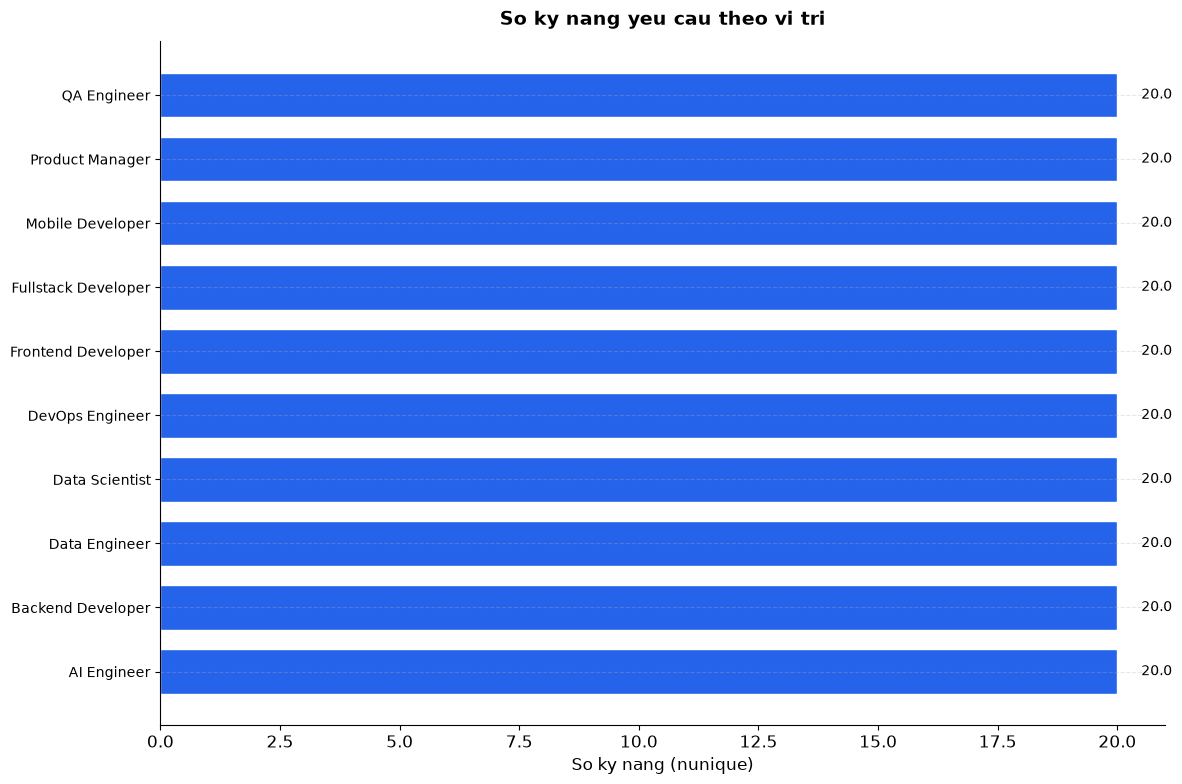

In [18]:
if "skills" in df.columns and "job_title" in df.columns and not df.empty:
    se = df.explode("skills")
    sc = se.groupby("job_title", observed=True)["skills"]\
        .nunique().sort_values(ascending=False).reset_index()
    sc.columns = ["job_title", "nunique_skills"]
    print("=== So ky nang yeu cau theo vi tri ===")
    print(sc.head(20))
    fig, ax = plt.subplots(figsize=(12, 8))
    styled_barh(sc, y="job_title", x="nunique_skills",
                title="So ky nang yeu cau theo vi tri",
                xlabel="So ky nang (nunique)", ylabel="", top_n=20, ax=ax)
    plt.tight_layout(); plt.show()


### Pivot 3: Ty le hinh thuc lam viec theo thanh pho

Crosstab city x remote_option voi normalize="index", the hien ty le % tung hinh thuc (On-site, Hybrid, Remote) trong moi thanh pho. Heatmap duoi day the hien 100% stacked view.


=== Ty le hinh thuc lam viec theo thanh pho (%) ===
remote_option  Hybrid  On-site  Remote
city                                  
Da Nang          28.6     48.6    22.9
HCMC             32.0     42.0    26.0
Hanoi            24.6     52.3    23.1


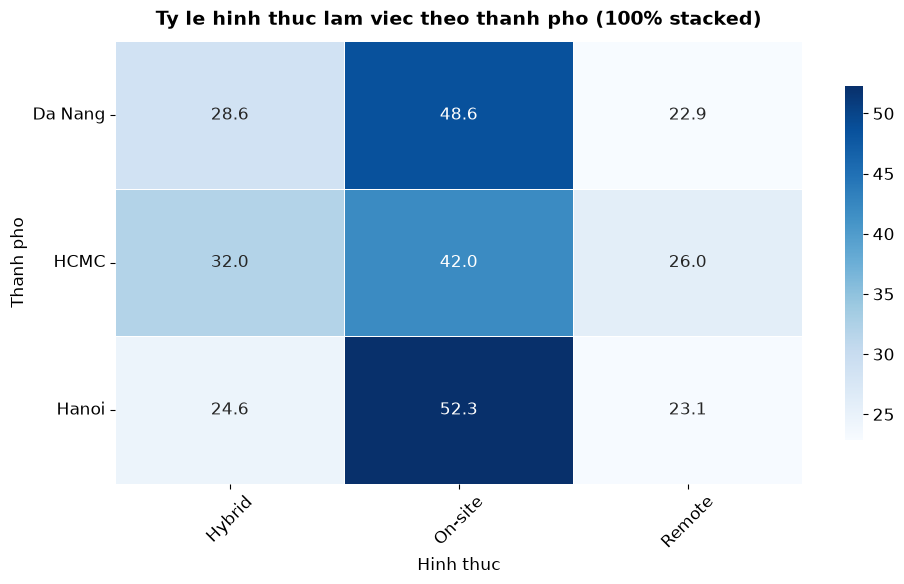

In [19]:
if "city" in df.columns and "remote_option" in df.columns and not df.empty:
    ct = pd.crosstab(df["city"], df["remote_option"], normalize="index") * 100
    ct = ct.round(1)
    print("=== Ty le hinh thuc lam viec theo thanh pho (%) ===")
    print(ct)
    fig, ax = plt.subplots(figsize=(10, 6))
    styled_heatmap(ct,
                   title="Ty le hinh thuc lam viec theo thanh pho (100% stacked)",
                   xlabel="Hinh thuc", ylabel="Thanh pho", fmt=".1f", cmap="Blues", ax=ax)
    plt.tight_layout(); plt.show()


### Pivot 4: Phan phoi hinh thuc cong viec (job_type)

Bieu do tan so (value_counts) cho cot job_type: Full-time, Part-time, Contract, Internship.


In [20]:
if "job_type" in df.columns and not df.empty:
    jt = df["job_type"].value_counts().reset_index()
    jt.columns = ["job_type", "count"]
    print("=== Phan phoi job_type ===")
    print(jt)
    fig, ax = plt.subplots(figsize=(10, 6))
    styled_barplot(jt, x="job_type", y="count",
                   title="Phan phoi hinh thuc cong viec (job_type)",
                   xlabel="Loai cong viec", ylabel="So tin", sort=False, ax=ax)
    plt.tight_layout(); plt.show()


**Nhan xet Chart 10:** Da so khong yeu cau cu the hoac chi Bachelor.


---

## 8. Ket luan EDA

| Cau hoi | Phat hien |
|---------|-----------|
| **F1** | Python, JavaScript, SQL la top 3 ky nang. Programming Language chiem ty trong lon. |
| **F2** | Luong tang theo kinh nghiem (entry->lead). HCMC cao nhat. Remote/Hybrid cao hon On-site. |
| **F3** | Yeu cau tieng Anh di kem luong cao hon dang ke. |
| **F4** | Vi tri quan ly/chuyen mon cao co ty le an luong >50%. |

### Y nghia cho ML

1. Feature Engineering: skills, has_english, city, experience_bin.
2. Xu ly missing: salary_hidden=True can imputation rieng.
3. Imbalance: Da Nang, entry/lead it mau -> stratified split.
4. Target encoding: City, experience_bin tuong quan ro voi luong.
5. Covariate shift: Nhieu nguon co the co phan phoi luong khac.

---

**Next:** Chuyen sang 04_machine_learning.ipynb de xay dung mo hinh du doan luong va goi y viec lam.
